In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="pastel")
import gc # for garbadge collection

### loading data 


In [3]:
df_train = pd.read_csv(r'D:\AI_ML\New_repo\fantastic-pancake\data\application_train.csv\application_train.csv')

In [4]:
df_train.head(6)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
5,100008,0,Cash loans,M,N,Y,0,99000.0,490495.5,27517.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0


In [5]:
print('there are '+ str(df_train.shape[1]) + ' columns \n' )
print('There are ' + str(df_train.shape[0])+ ' rows \n') 

there are 122 columns 

There are 307511 rows 



In [6]:
test_df = pd.read_csv(r"D:\AI_ML\New_repo\fantastic-pancake\data\application_test.csv\application_test.csv")
test_df

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0


### Analyzing the distribution of Target field!!

In [7]:
df_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: xlabel='TARGET', ylabel='count'>

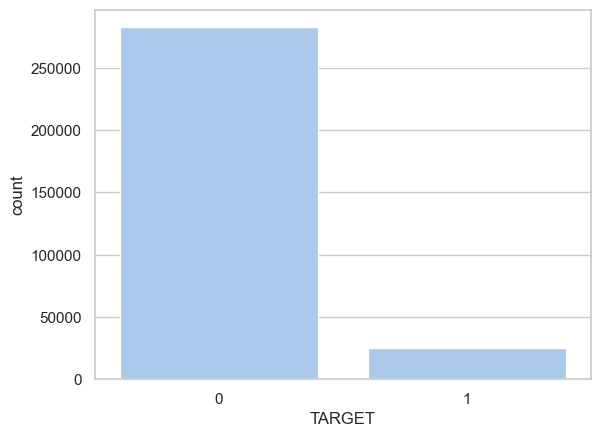

In [8]:
sns.countplot(x='TARGET', data=df_train)

Next step : Correlation of features to check which feature is more related to each other . it will help undestand which feature will have more impact on the learning of the model!

In [7]:
numeric_df = df_train.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()['TARGET'].sort_values()

print('Top positive correlations:\n', corr.tail(15))
print('\nTop negative correlations:\n', corr.head(15))


Top positive correlations:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Top negative correlations:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
RE

#### unpacking the text fields and analyzing the data

In [8]:
text_fields = df_train.select_dtypes(include=['object']).columns
text_fields

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

In [9]:
df_train[text_fields].head()


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,WEEKDAY_APPR_PROCESS_START,ORGANIZATION_TYPE,FONDKAPREMONT_MODE,HOUSETYPE_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN


In [12]:
# counting the unique values of each columns 
for col in text_fields:
    print(col, " --> ", df_train[col].unique(), "Unique values")

NAME_CONTRACT_TYPE  -->  <StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str Unique values
CODE_GENDER  -->  <StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str Unique values
FLAG_OWN_CAR  -->  <StringArray>
['N', 'Y']
Length: 2, dtype: str Unique values
FLAG_OWN_REALTY  -->  <StringArray>
['Y', 'N']
Length: 2, dtype: str Unique values
NAME_TYPE_SUITE  -->  <StringArray>
[  'Unaccompanied',          'Family', 'Spouse, partner',        'Children',
         'Other_A',               nan,         'Other_B', 'Group of people']
Length: 8, dtype: str Unique values
NAME_INCOME_TYPE  -->  <StringArray>
[             'Working',        'State servant', 'Commercial associate',
            'Pensioner',           'Unemployed',              'Student',
          'Businessman',      'Maternity leave']
Length: 8, dtype: str Unique values
NAME_EDUCATION_TYPE  -->  <StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',        

In [13]:
df_train.nunique().sort_values()

TARGET                     2
NAME_CONTRACT_TYPE         2
FLAG_OWN_REALTY            2
FLAG_OWN_CAR               2
FLAG_WORK_PHONE            2
                       ...  
DAYS_REGISTRATION      15688
DAYS_BIRTH             17460
EXT_SOURCE_1          114584
EXT_SOURCE_2          119831
SK_ID_CURR            307511
Length: 122, dtype: int64

In [14]:
print("This is till EDA v2")

This is till EDA v2


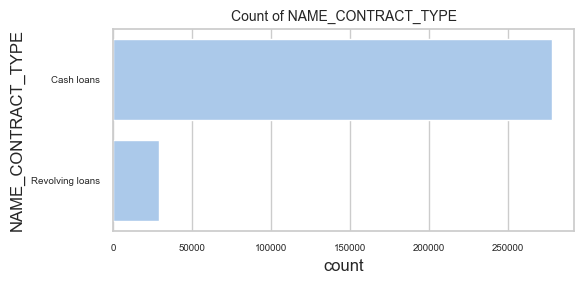

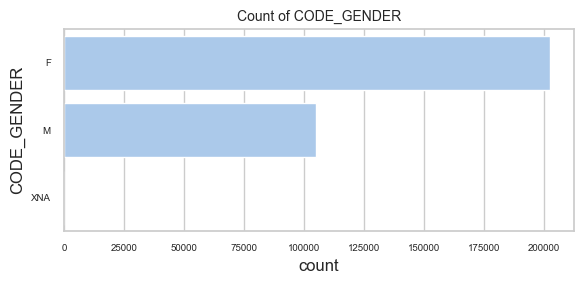

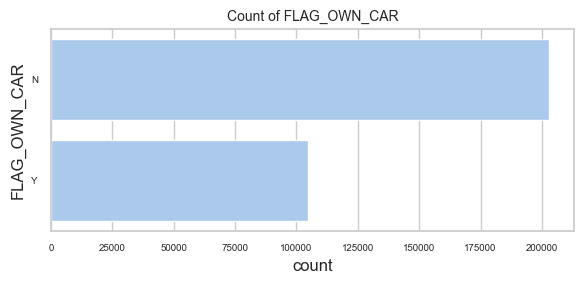

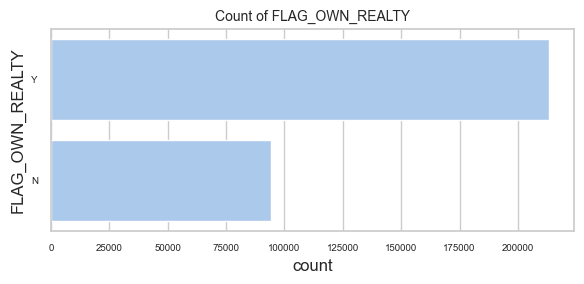

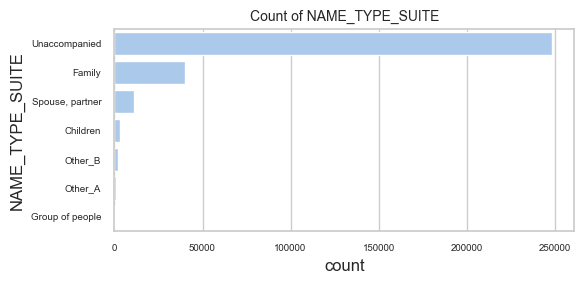

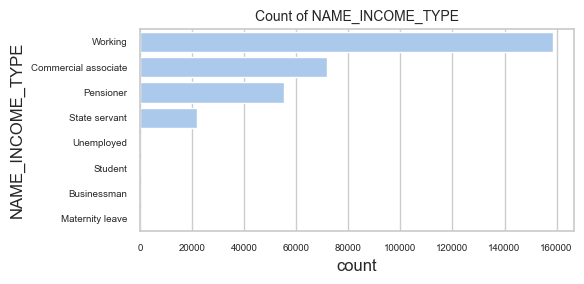

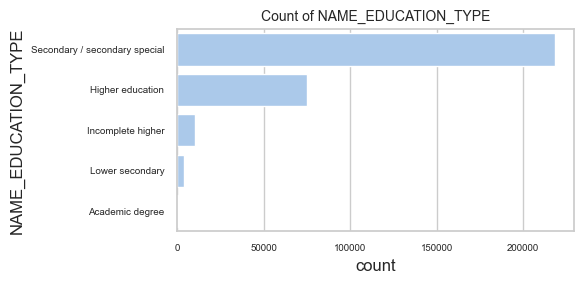

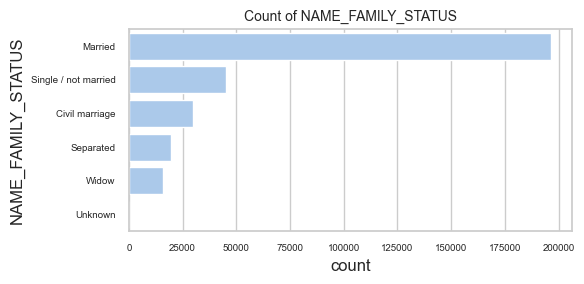

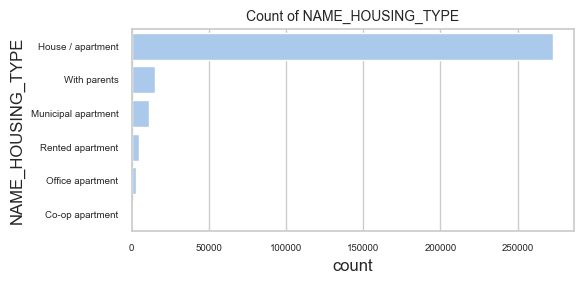

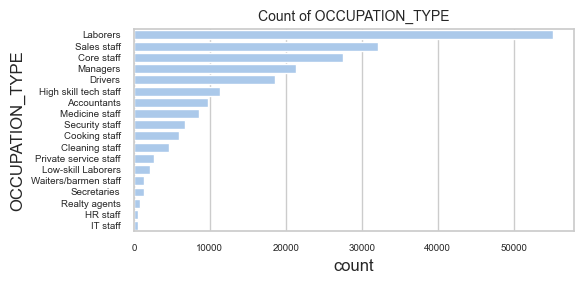

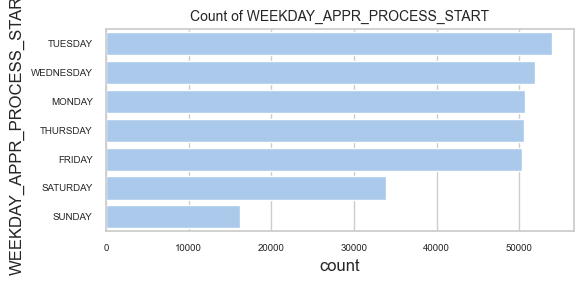

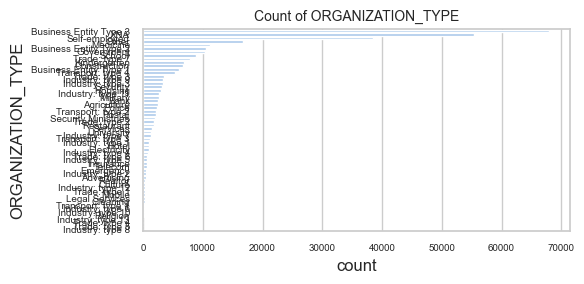

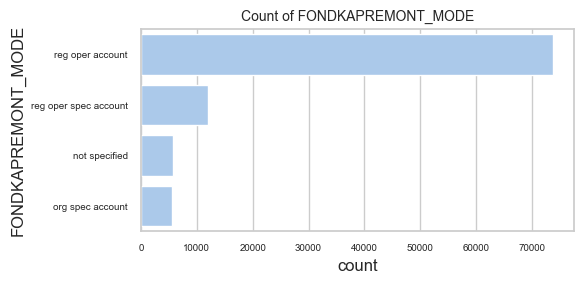

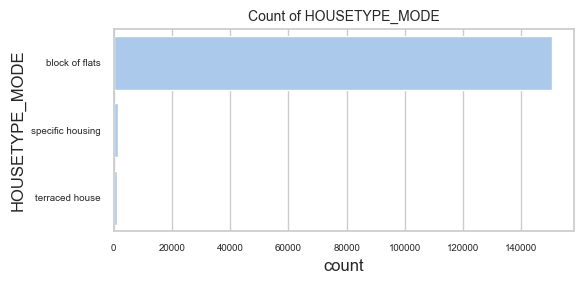

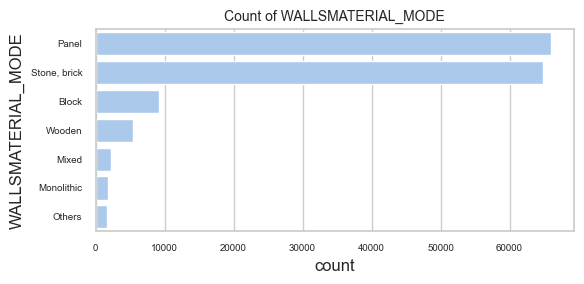

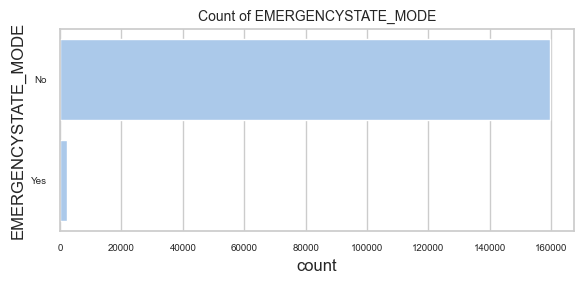

In [14]:
for col in text_fields:
    plt.figure(figsize=(6,3))
    sns.countplot(
        data=df_train,
        y=col,
        order=df_train[col].value_counts().index
    )
    plt.title(f'Count of {col}', fontsize=10)
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.show()


## Anomaly exploration in data.  Anomaly Detection, Validation, and Treatment (EDA → Modeling)

Age --> 

In [ ]:
# Step 1. Detecting the suspicious values
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [ ]:
#ANOMALY HANDLING 
days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
             'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
 
for col in days_cols:
    if col in df_train.columns:
        df_train[col] = df_train[col].abs()
    if col in test_df.columns:
        test_df[col]  = test_df[col].abs()
 
for df in [df_train, test_df]:
    df['EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan
 
print(f"\nEMPLOYED_ANOM counts (train):\n{df_train['EMPLOYED_ANOM'].value_counts()}")
 


EMPLOYED_ANOM counts (train):
EMPLOYED_ANOM
0    252137
1     55374
Name: count, dtype: int64


In [12]:
# Find the correlation of the positive days since birth and target
df_train['DAYS_BIRTH'] = abs(df_train['DAYS_BIRTH'])
df_train['DAYS_BIRTH'].corr(df_train['TARGET'])

np.float64(-0.07823930830982709)

In [13]:
df_numeric = df_train.select_dtypes(include=[np.number]).columns
df_numeric 
# for col in df_numeric:
#     print(col)

Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
       'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
       'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
       'EMPLOYED_ANOM'],
      dtype='str', length=107)

In [14]:
desc = df_train[df_numeric].describe().T
desc 

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.0,0.0,1.0,3.0,25.0


In [15]:
df_train['DAYS_EMPLOYED'].value_counts().head()


DAYS_EMPLOYED
200.0    156
224.0    152
199.0    151
230.0    151
212.0    150
Name: count, dtype: int64

In [16]:

age_df = df_train[['TARGET', 'DAYS_BIRTH']]
age_df['YEARS_BIRTH'] = age_df['DAYS_BIRTH'] / 365

age_df['YEARS_BINNED'] = pd.cut(age_df['YEARS_BIRTH'], bins= np.linspace(20, 70, num=11))
age_df.head(15)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [17]:
age_groups = age_df.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


In [18]:
for df in [df_train, test_df]:
 
    # --- Credit burden ratios ---
    df['CREDIT_INCOME_RATIO']   = df['AMT_CREDIT']  / (df['AMT_INCOME_TOTAL'] + 1)
    df['ANNUITY_INCOME_RATIO']  = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)
    df['CREDIT_TERM']           = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
    df['GOODS_CREDIT_RATIO']    = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)
 
    # --- Employment stability ---
    df['DAYS_EMPLOYED_RATIO']   = df['DAYS_EMPLOYED'] / (df['DAYS_BIRTH'] + 1)
 
    # --- EXT_SOURCE aggregations (strongest predictors) ---
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    df['EXT_SOURCE_MEAN']       = df[ext_cols].mean(axis=1)
    df['EXT_SOURCE_STD']        = df[ext_cols].std(axis=1).fillna(0)
    df['EXT_SOURCE_MIN']        = df[ext_cols].min(axis=1)
    df['EXT_SOURCE_PROD']       = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
 
    # --- Age-related ---
    df['YEARS_BIRTH']           = df['DAYS_BIRTH'] / 365
    df['YEARS_EMPLOYED']        = df['DAYS_EMPLOYED'] / 365
 
    # --- Income per family member ---
    df['INCOME_PER_PERSON']     = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'].replace(0, 1))
 
    # --- Payment burden ---
    df['PAYMENT_RATE']          = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)
 
print(f"\nNew feature columns added. Train shape now: {df_train.shape}")


New feature columns added. Train shape now: (307511, 136)


## plotting distribution of age

Text(0, 0.5, 'Count')

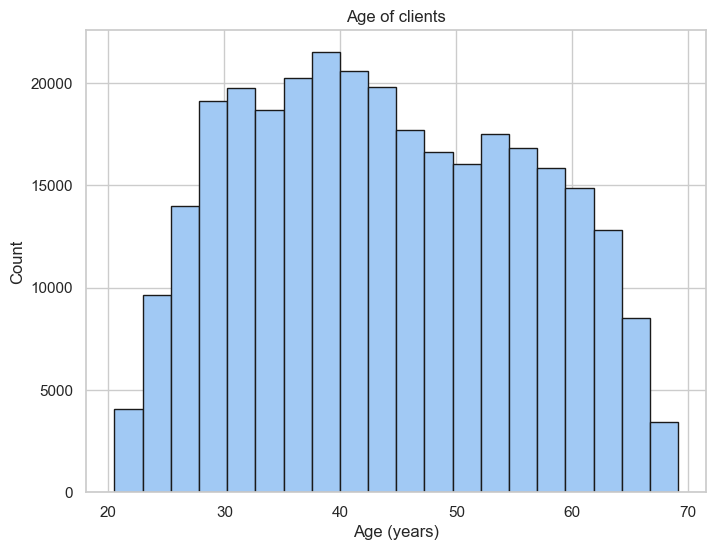

In [19]:
plt.figure(figsize=(8,6))
plt.hist(df_train['DAYS_BIRTH'] / 365, edgecolor='k', bins=20)
plt.title('Age of clients')
plt.xlabel('Age (years)')
plt.ylabel('Count')


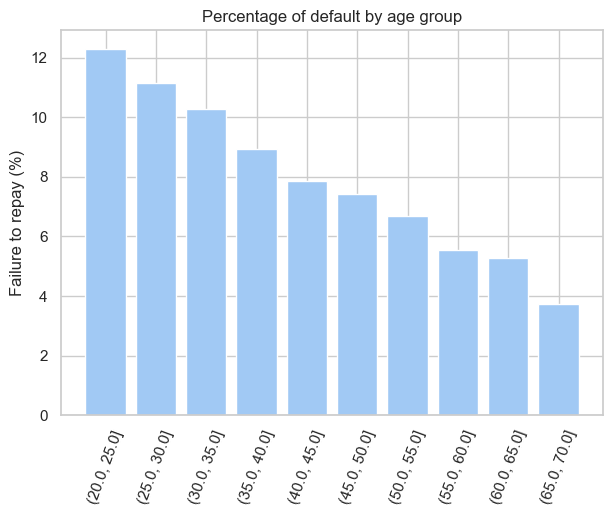

In [20]:
plt.figure(figsize=(7,5))

plt.bar(age_groups.index.astype(str), 100* age_groups['TARGET'])
plt.title('Percentage of default by age group')
plt.xticks(rotation=70)
plt.ylabel("Failure to repay (%)")
plt.show()

#### so we can see that, most people who failed to pay the loan are mostly between the age 20-45

### checking the days employed field for anomaly

In [24]:
df_train["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

so we can see there is anomaly in the days employed. The mean and Max is abnormal

In [22]:
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].abs()

In [23]:
df_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

0          637.0
1         1188.0
2          225.0
3         3039.0
4         3038.0
           ...  
307506     236.0
307507       NaN
307508    7921.0
307509    4786.0
307510    1262.0
Name: DAYS_EMPLOYED, Length: 307511, dtype: float64

In [24]:
df_train['DAYS_EMPLOYED'].mean() / 365


np.float64(6.531970752364948)

In [25]:
df_train["DAYS_EMPLOYED"].describe()

count    252137.000000
mean       2384.169325
std        2338.360162
min           0.000000
25%         767.000000
50%        1648.000000
75%        3175.000000
max       17912.000000
Name: DAYS_EMPLOYED, dtype: float64

### Histogram before handling anomaly of days employement

Text(0.5, 0, 'number of days employed')

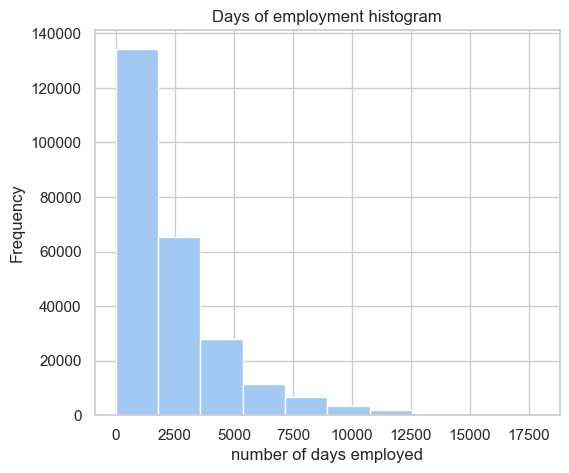

In [26]:
fig, ax = plt.subplots(figsize=(6,5))
df_train['DAYS_EMPLOYED'].plot.hist(title = 'Days of employment histogram')
plt.xlabel('number of days employed')

In [30]:
df_train.loc[df_train['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan


In [31]:
df_train['EMPLOYED_ANOM'] = (df_train['DAYS_EMPLOYED'] == 365243)
df_train.loc[df_train['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan


In [41]:
# df_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
#

### Graph after applying anomaly handling. -->

Text(0.5, 0, 'number of days employed')

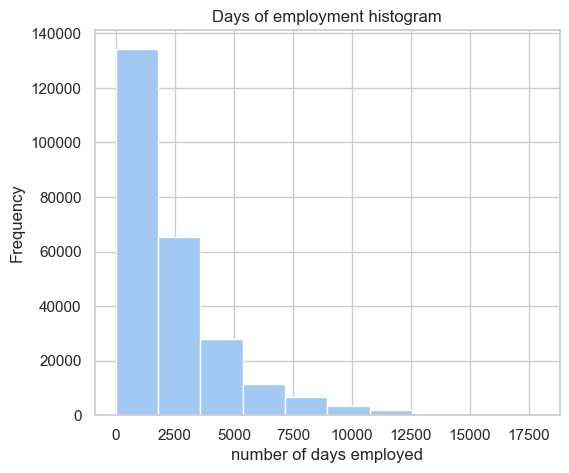

In [27]:
fig, ax = plt.subplots(figsize=(6,5))
df_train['DAYS_EMPLOYED'].plot.hist(title = 'Days of employment histogram')
plt.xlabel('number of days employed')

In [28]:
df_train["DAYS_EMPLOYED"].describe()

count    252137.000000
mean       2384.169325
std        2338.360162
min           0.000000
25%         767.000000
50%        1648.000000
75%        3175.000000
max       17912.000000
Name: DAYS_EMPLOYED, dtype: float64

EXT_SOURCES and DAYS_BIRTH relation

--> All of the ext_sources feature have negative correlations with the target value.

Clients are more likely to repay loan as the value of the EXT_SOURCES increases. 
- Days_Birth is positively correlated with EXT_SOUCE_1, this means that a key factor here is might be the age of the clients


In [29]:
ext_data = df_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs 

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


Text(0.5, 1.0, 'Correlation heatmap of external sources and target')

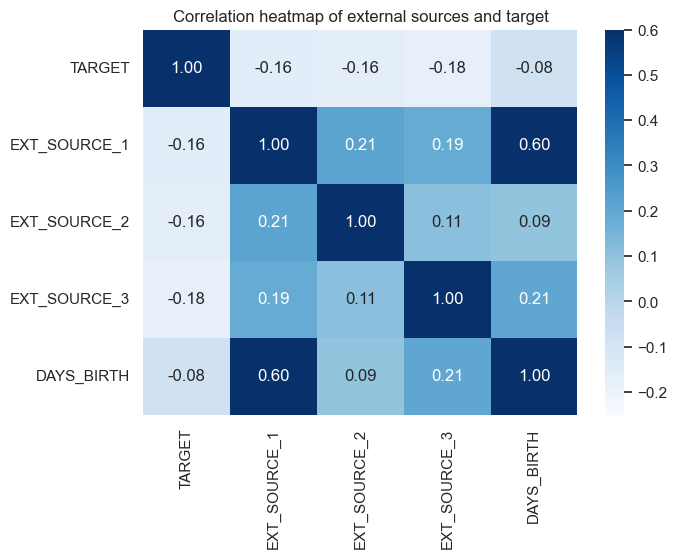

In [30]:
plt.figure(figsize=(7,5))
sns.heatmap(ext_data_corrs, cmap='Blues', annot=True, vmin=-0.25, vmax=0.6, fmt='.2f')
plt.title('Correlation heatmap of external sources and target')

In [31]:
null_sums = df_train.isnull().sum().sort_values(ascending=True)
null_sums


SK_ID_CURR                       0
TARGET                           0
NAME_CONTRACT_TYPE               0
CODE_GENDER                      0
FLAG_OWN_CAR                     0
                             ...  
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
Length: 197, dtype: int64

## Finding the feature importance from the data using Random forest algorithm


Preprocessing and handling the empty fields!

In [32]:
from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
# dropping useless columns
# df_train = df_train.drop(columns=["SK_ID_CURR"])
test_df = test_df.drop(columns=["SK_ID_CURR"])

In [34]:
missing_ratio_before = df_train.isnull().mean()
cols_to_flag = missing_ratio_before[missing_ratio_before > 0.01].index.tolist()
 
# Exclude TARGET from flagging
cols_to_flag = [c for c in cols_to_flag if c != 'TARGET']
 
for col in cols_to_flag:
    flag_col = col + '_MISSING'
    df_train[flag_col] = df_train[col].isnull().astype(int)
    test_df[flag_col]  = test_df[col].isnull().astype(int)
 
print(f"\nMissing flag columns created: {len(cols_to_flag)}")
 


Missing flag columns created: 61


In [35]:
missing_ratio = df_train.isnull().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.6].index.tolist()
# Never drop TARGET or SK_ID_CURR here
high_missing_cols = [c for c in high_missing_cols if c not in ['TARGET', 'SK_ID_CURR']]
 
df_train = df_train.drop(columns=high_missing_cols)
test_df  = test_df.drop(columns=[c for c in high_missing_cols if c in test_df.columns])
 
print(f"\nDropped {len(high_missing_cols)} high-missing columns.")
print(f"Train shape after drop: {df_train.shape}")


Dropped 18 high-missing columns.
Train shape after drop: (307511, 179)


In [36]:
num_cols = df_train.select_dtypes(include='number').columns
obj_cols = df_train.select_dtypes(include=['object']).columns
 
test_num_cols = test_df.select_dtypes(include='number').columns
test_obj_cols = test_df.select_dtypes(include=['object']).columns
 
df_train[num_cols] = df_train[num_cols].fillna(-999)
df_train[obj_cols] = df_train[obj_cols].fillna('missing')
 
test_df[test_num_cols] = test_df[test_num_cols].fillna(-999)
test_df[test_obj_cols] = test_df[test_obj_cols].fillna('missing')

In [37]:
categorical_features = df_train.select_dtypes(include=['object']).columns.tolist()
 
for col in categorical_features:
    le = preprocessing.LabelEncoder()
    combined = list(df_train[col].values) + list(test_df[col].values) \
               if col in test_df.columns else list(df_train[col].values)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col].values)
    if col in test_df.columns:
        test_df[col] = le.transform(test_df[col].values)

In [38]:
# STEP 7 — DROP CONSTANT COLUMNS
# ===========================================================================
constant_cols = [c for c in df_train.columns if df_train[c].nunique() <= 1]
df_train = df_train.drop(columns=constant_cols)
test_df  = test_df.drop(columns=[c for c in constant_cols if c in test_df.columns])
print(f"\nDropped {len(constant_cols)} constant columns.")


Dropped 0 constant columns.


In [40]:
# Step 3: Label Encode
categorical_features = [f for f in df_train.columns 
                        if df_train[f].dtype == 'object' or pd.api.types.is_string_dtype(df_train[f])]

# for col in obj_cols:
#     df_train[col] = df_train[col].astype('category')
#     test_df[col] = test_df[col].astype('category')

for col in categorical_features:
    le = preprocessing.LabelEncoder()
    le.fit(list(df_train[col].values) + list(test_df[col].values))
    df_train[col] = le.transform(list(df_train[col].values))
    test_df[col] = le.transform(list(test_df[col].values))

# Step 4: Force all columns to numeric
df_train =  df_train.apply(pd.to_numeric, errors='coerce')
test_df = test_df.apply(pd.to_numeric, errors='coerce')

#Step 5: Checking for any remaining non-numeric columns
print("Remaining non-numeric columns:", df_train.select_dtypes(include=['object','string']).columns.tolist())


Remaining non-numeric columns: []


In [41]:
df_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EMPLOYED_ANOM
0,100002,1,0,1,0,1,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,False
1,100003,0,0,0,0,0,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,False
2,100004,0,1,1,1,1,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,False
3,100006,0,0,0,0,1,0,135000.0,312682.5,29686.5,...,0,0,0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,False
4,100007,0,0,1,0,1,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,1,0,0,0,157500.0,254700.0,27558.0,...,0,0,0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,False
307507,456252,0,0,0,0,1,0,72000.0,269550.0,12001.5,...,0,0,0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,False
307508,456253,0,0,0,0,1,0,153000.0,677664.0,29979.0,...,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,False
307509,456254,1,0,0,0,1,0,171000.0,370107.0,20205.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,False


In [42]:
# drop high-missing
missing_ratio = df_train.isnull().mean()
df_train = df_train.drop(columns=missing_ratio[missing_ratio > 0.8].index)

# drop constant
df_train = df_train.loc[:, df_train.nunique() > 1]

In [40]:
drop_cols = ['TARGET', 'SK_ID_CURR']
X = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])
y = df_train['TARGET']
 
# Keep SK_ID_CURR for submission
# test_ids = test_df['SK_ID_CURR'].copy()
X_test   = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
 
# Align test to train columns
X_test = X_test.reindex(columns=X.columns, fill_value=-999)
 
print(f"\nFinal feature count: {X.shape[1]}")
print(f"X_train shape: {X.shape}, X_test shape: {X_test.shape}")


Final feature count: 177
X_train shape: (307511, 177), X_test shape: (48744, 177)


In [43]:
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, precision_recall_curve
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
 
oof_preds   = np.zeros(len(X))           # out-of-fold predictions
test_preds  = np.zeros(len(X_test))      # averaged test predictions
fold_scores = []
 
lgb_params = dict(
    n_estimators      = 2000,
    learning_rate     = 0.03,
    num_leaves        = 64,
    max_depth         = -1,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    scale_pos_weight  = (y == 0).sum() / (y == 1).sum(),  # auto-computed
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
 
print(f"\nscale_pos_weight set to: {lgb_params['scale_pos_weight']:.2f}")
print(f"\n{'='*55}")
print(f"  Starting {N_FOLDS}-Fold Cross Validation")
print(f"{'='*55}")
 
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
 
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
    model = lgb.LGBMClassifier(**lgb_params)
 
    model.fit(
        X_tr, y_tr,
        eval_set        = [(X_val, y_val)],
        eval_metric     = 'auc',
        callbacks       = [
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )
 
    val_proba              = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx]     = val_proba
    test_preds            += model.predict_proba(X_test)[:, 1] / N_FOLDS
 
    fold_auc = roc_auc_score(y_val, val_proba)
    fold_scores.append(fold_auc)
    print(f"  Fold {fold}  |  Val AUC: {fold_auc:.5f}  |  "
          f"Best iter: {model.best_iteration_}")
 
oof_auc = roc_auc_score(y, oof_preds)
print(f"\n{'='*55}")
print(f"  OOF AUC : {oof_auc:.5f}")
print(f"  Mean CV : {np.mean(fold_scores):.5f}  ±  {np.std(fold_scores):.5f}")
print(f"{'='*55}")


scale_pos_weight set to: 11.39

  Starting 5-Fold Cross Validation
  Fold 1  |  Val AUC: 0.73411  |  Best iter: 2
  Fold 2  |  Val AUC: 0.73523  |  Best iter: 2
  Fold 3  |  Val AUC: 0.73166  |  Best iter: 2
  Fold 4  |  Val AUC: 0.73827  |  Best iter: 2
  Fold 5  |  Val AUC: 0.72640  |  Best iter: 2

  OOF AUC : 0.73308
  Mean CV : 0.73314  ±  0.00398


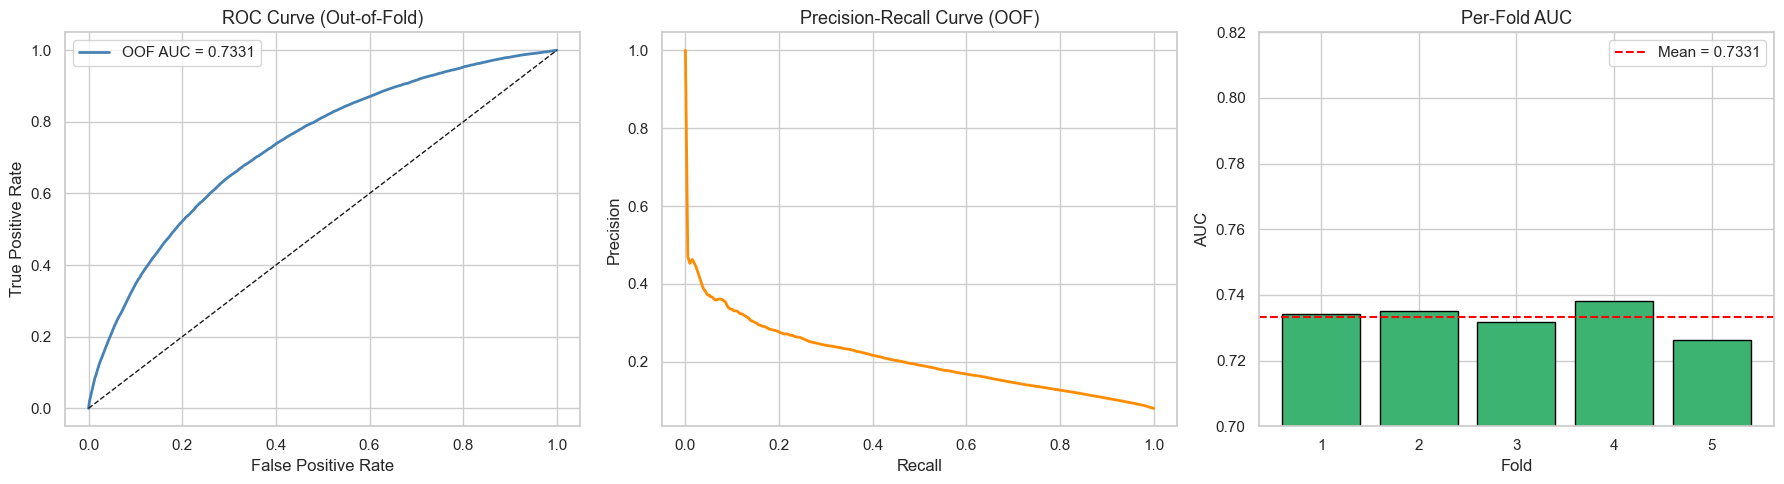

Saved: evaluation_plots.png

  Threshold Analysis (OOF predictions)

Threshold: 0.3
              precision    recall  f1-score   support

           0      0.919     1.000     0.958    282686
           1      0.000     0.000     0.000     24825

    accuracy                          0.919    307511
   macro avg      0.460     0.500     0.479    307511
weighted avg      0.845     0.919     0.881    307511


Threshold: 0.4
              precision    recall  f1-score   support

           0      0.919     1.000     0.958    282686
           1      0.000     0.000     0.000     24825

    accuracy                          0.919    307511
   macro avg      0.460     0.500     0.479    307511
weighted avg      0.845     0.919     0.881    307511


Threshold: 0.5
              precision    recall  f1-score   support

           0      0.919     1.000     0.958    282686
           1      0.000     0.000     0.000     24825

    accuracy                          0.919    307511
   macro avg

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# --- ROC Curve (OOF) ---
fpr, tpr, _ = roc_curve(y, oof_preds)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'OOF AUC = {oof_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve (Out-of-Fold)', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
 
# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y, oof_preds)
axes[1].plot(recall, precision, color='darkorange', lw=2)
axes[1].set_title('Precision-Recall Curve (OOF)', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
 
# --- Fold Scores ---
axes[2].bar(range(1, N_FOLDS + 1), fold_scores, color='mediumseagreen',
            edgecolor='black')
axes[2].axhline(np.mean(fold_scores), color='red', linestyle='--',
                label=f'Mean = {np.mean(fold_scores):.4f}')
axes[2].set_title('Per-Fold AUC', fontsize=13)
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].set_ylim(0.7, 0.82)
 
plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()
print("Saved: evaluation_plots.png")
 
# ===========================================================================
# STEP 11 — THRESHOLD ANALYSIS on OOF predictions
# ===========================================================================
print(f"\n{'='*55}")
print("  Threshold Analysis (OOF predictions)")
print(f"{'='*55}")
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (oof_preds > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y, y_pred, digits=3))

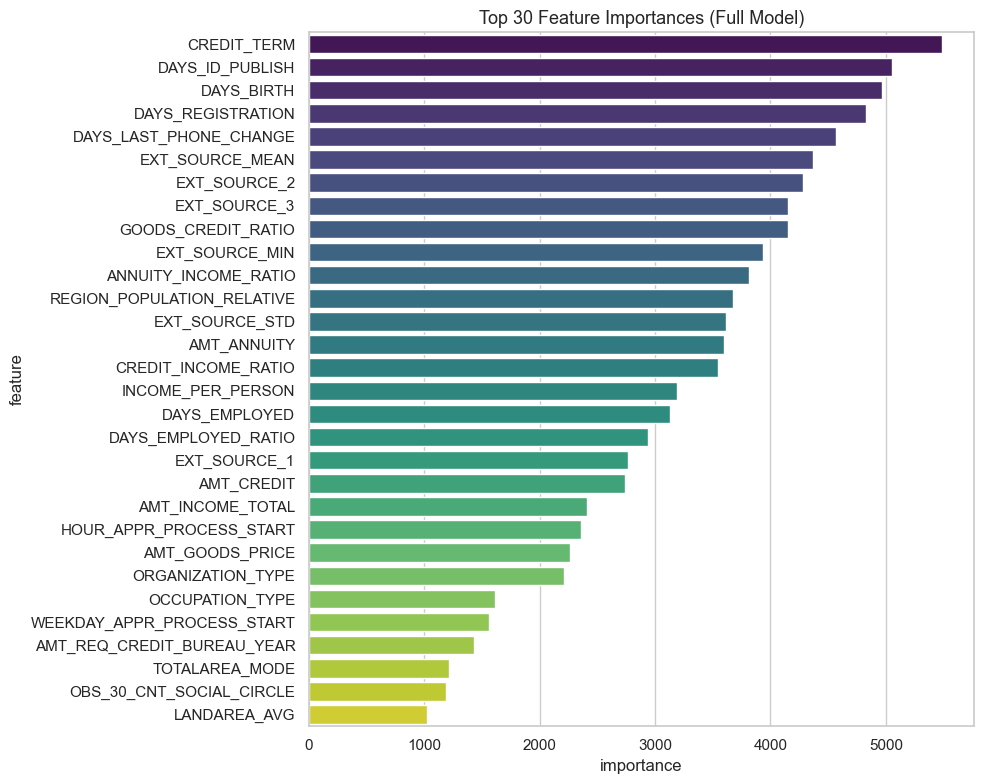

Saved: feature_importance.png


In [48]:
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X, y,
                callbacks=[lgb.log_evaluation(period=500)])
 
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).head(30)
 
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 30 Feature Importances (Full Model)', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved: feature_importance.png")

In [45]:

from sklearn.model_selection import train_test_split


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  
)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}")

Train size: (246008, 177), Validation size: (61503, 177)


In [46]:
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves= 64,
    subsample= 0.8,
    colsample_bytree=0.8,
    scale_pos_weight = 11.4,
    random_state= 42

)


In [47]:
lgb_model.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)],
    eval_metric='auc'
)

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [49]:
y_pred_proba = lgb_model.predict_proba(X_val)[:, 1]

In [50]:
threshold = 0.3
y_pred = (y_pred_proba > threshold).astype(int)

In [51]:
print(y_pred)

[1 1 1 ... 0 1 1]


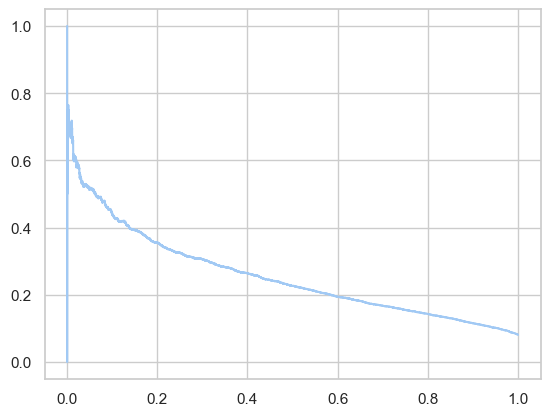

In [52]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, classification_report, roc_curve
name = "LightGBM"
precision, recall , _ = precision_recall_curve(y_val, y_pred_proba)
plt.plot(recall, precision, label=name)


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.54      0.69     56538
           1       0.14      0.83      0.23      4965

    accuracy                           0.56     61503
   macro avg       0.55      0.68      0.46     61503
weighted avg       0.90      0.56      0.66     61503


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.97      0.67      0.79     56538
           1       0.16      0.72      0.27      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.70      0.53     61503
weighted avg       0.90      0.68      0.75     61503


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     56538
           1       0.19      0.60      0.29      4965

    accuracy                           0.77     61503
   macro avg       0.58      0.69      0.58     61503
weighted avg       0.90   

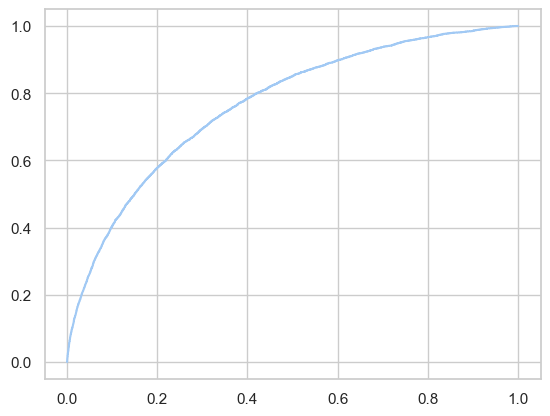

In [53]:
auc = roc_auc_score(y_val, y_pred_proba)

# threshold = 0.3
# y_pred = (y_pred_proba > threshold).astype(int)

# print(f"\n{'='*40}")
# print(f"Model: {name}")
# print(f"ROC-AUC Score: {auc:.4f}")
# print(f"\nClassification Report:\n{classification_report(y_val, y_pred)}")
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_pred_proba > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_val, y_pred))
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

In [54]:
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in [i/100 for i in range(10, 90)]:
    y_pred = (y_pred_proba > t).astype(int)
    f1 = f1_score(y_val, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)

Best threshold: 0.63


In [55]:
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=8,
    min_samples_leaf=4,
    max_features=0.5,
    random_state=2018
)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.5
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true

In [56]:
# Extract and display feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns.values,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20))

                  feature  importance
109       EXT_SOURCE_MEAN    0.465196
111        EXT_SOURCE_MIN    0.121420
107    GOODS_CREDIT_RATIO    0.049701
40           EXT_SOURCE_3    0.043654
39           EXT_SOURCE_2    0.038039
110        EXT_SOURCE_STD    0.021034
106           CREDIT_TERM    0.018286
115          PAYMENT_RATE    0.016796
112           YEARS_BIRTH    0.015975
15             DAYS_BIRTH    0.014514
7             AMT_ANNUITY    0.013808
18        DAYS_ID_PUBLISH    0.010280
17      DAYS_REGISTRATION    0.009919
105  ANNUITY_INCOME_RATIO    0.009311
38           EXT_SOURCE_1    0.009014
6              AMT_CREDIT    0.008483
11    NAME_EDUCATION_TYPE    0.007517
104   CREDIT_INCOME_RATIO    0.007097
108   DAYS_EMPLOYED_RATIO    0.006831
8         AMT_GOODS_PRICE    0.006385


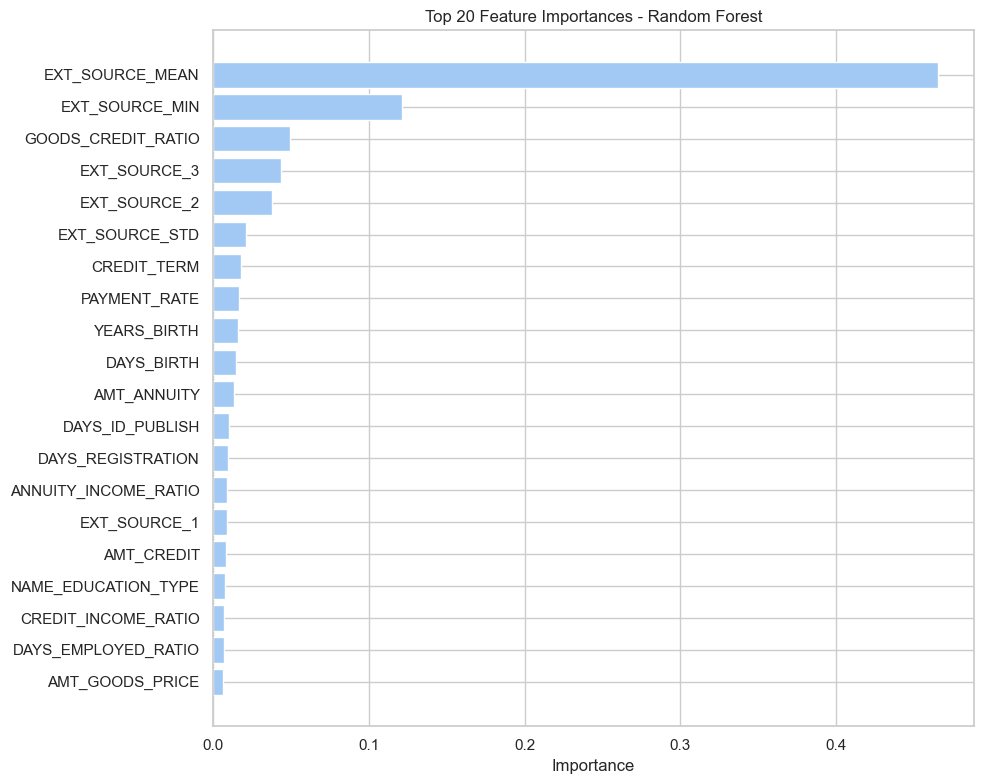

In [57]:

# Step 9: Plot
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance['feature'].head(20)[::-1],
    feature_importance['importance'].head(20)[::-1]
)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [58]:
# Finding cumulative importance alogn with feature importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print(feature_importance.head(30))

                        feature  importance  cumulative_importance
109             EXT_SOURCE_MEAN    0.465196               0.465196
111              EXT_SOURCE_MIN    0.121420               0.586616
107          GOODS_CREDIT_RATIO    0.049701               0.636317
40                 EXT_SOURCE_3    0.043654               0.679970
39                 EXT_SOURCE_2    0.038039               0.718009
110              EXT_SOURCE_STD    0.021034               0.739043
106                 CREDIT_TERM    0.018286               0.757329
115                PAYMENT_RATE    0.016796               0.774124
112                 YEARS_BIRTH    0.015975               0.790100
15                   DAYS_BIRTH    0.014514               0.804614
7                   AMT_ANNUITY    0.013808               0.818421
18              DAYS_ID_PUBLISH    0.010280               0.828701
17            DAYS_REGISTRATION    0.009919               0.838621
105        ANNUITY_INCOME_RATIO    0.009311               0.84

Now selecting the features based on the feature importance! 
- using cumulative importance as threshold so that I don't miss any important features with less feature importance that has impact on the datset.

In [59]:
selected_features = feature_importance[
    feature_importance['cumulative_importance'] <= 0.95
]['feature'].tolist()

print(f"Selected features that contribute to 95% of importance: {selected_features}")
print("len of selected features: ", len(selected_features))

Selected features that contribute to 95% of importance: ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'GOODS_CREDIT_RATIO', 'EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_STD', 'CREDIT_TERM', 'PAYMENT_RATE', 'YEARS_BIRTH', 'DAYS_BIRTH', 'AMT_ANNUITY', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'ANNUITY_INCOME_RATIO', 'EXT_SOURCE_1', 'AMT_CREDIT', 'NAME_EDUCATION_TYPE', 'CREDIT_INCOME_RATIO', 'DAYS_EMPLOYED_RATIO', 'AMT_GOODS_PRICE', 'CODE_GENDER', 'DAYS_EMPLOYED', 'EXT_SOURCE_3_MISSING', 'YEARS_EMPLOYED', 'REGION_POPULATION_RELATIVE', 'INCOME_PER_PERSON', 'DAYS_LAST_PHONE_CHANGE', 'NAME_INCOME_TYPE', 'AMT_INCOME_TOTAL', 'ORGANIZATION_TYPE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'HOUR_APPR_PROCESS_START', 'FLAG_DOCUMENT_3', 'YEARS_BEGINEXPLUATATION_MODE']
len of selected features:  34


### Starting model training on Light GBM

In [60]:
x_selected = df_train[selected_features]
x_test_selected = test_df[selected_features]


In [61]:
y = df_train['TARGET']

In [62]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)

X_train, X_val, y_train, y_val = train_test_split(
    x_selected, y, test_size=0.2, random_state=42, stratify=y  
)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}")

Train size: (246008, 34), Validation size: (61503, 34)


### Defining the models

In [63]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
models = {
    'LigthGBM':lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        is_unbalance=True,   # handles class imbalance 
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=11.5,  # handles class imbalance
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # handles class imbalance
        random_state=42
    )
}

In [64]:
# now need scaling for logistic regression as it does not handle large feature values well,
# while tree-based models do not require scaling.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)



Model: LigthGBM
ROC-AUC Score: 0.7655

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.66      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.55     61503
weighted avg       0.90      0.72      0.78     61503


Model: XGBoost
ROC-AUC Score: 0.7639

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.18      0.64      0.28      4965

    accuracy                           0.74     61503
   macro avg       0.57      0.69      0.56     61503
weighted avg       0.90      0.74      0.79     61503


Model: Logistic Regression
ROC-AUC Score: 0.6717

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.61      0.75     56538
           1       0.13      0.63     

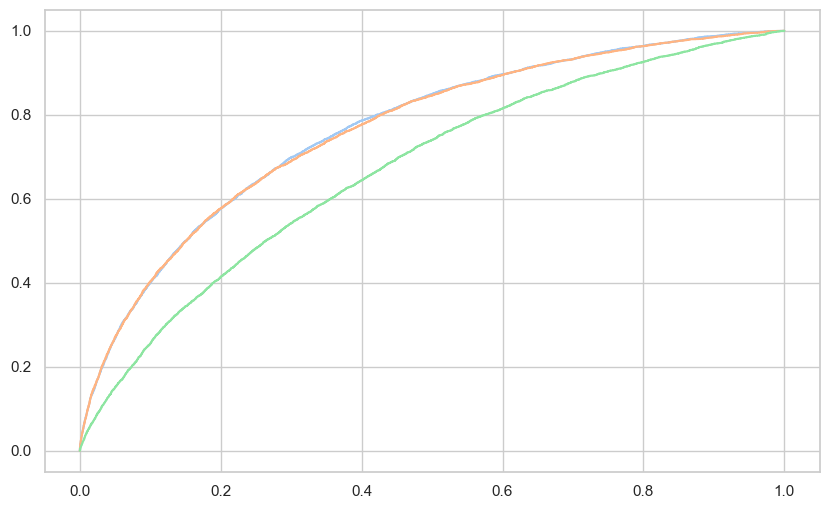

In [65]:
results = {}
plt.figure(figsize=(10, 6))

for name, model in models.items():
    #  scaled data for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)

    # ROC-AUC Score
    auc = roc_auc_score(y_val, y_pred_proba)
    results[name] = auc
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"ROC-AUC Score: {auc:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_val, y_pred)}")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

In [66]:
#hyperparameter tuning for lightgbm
from sklearn.model_selection import GridSearchCV
lgbm_fine_tuned = lgb.LGBMClassifier(
    is_unbalance = True,
    random_state=42
)

param_grid = {
    'num_leaves': [31, 50],
    'max_depth': [-1, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500]
}
grid_search = GridSearchCV(
    estimator=lgbm_fine_tuned,
    param_grid= param_grid,
    scoring= 'roc_auc',
    cv = 3,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC Score: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 300, 'num_leaves': 31}
Best ROC-AUC Score: 0.7582


In [67]:
from sklearn.model_selection import RandomizedSearchCV

params_dist = {
    'num_leaves': np.arange(20, 150),
    'learning_rate': np.linspace(0.01, 0.1 ,20),
    'n_estimators': np.arange(200, 1000),
    'subsample': np.linspace(0.5, 1.0, 10),
    'colsample_bytree': np.linspace(0.6, 1.0, 10),
    'max_depth': [-1, 10, 20, 30]
}

random_serach = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(is_unbalance=True, random_state=42),
    param_distributions=params_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=3,
    random_state=42
)

random_serach.fit(X_train, y_train)
print(f"Best parameters: {random_serach.best_params_}")
print(f"Best ROC-AUC Score: {random_serach.best_score_:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters: {'subsample': np.float64(0.8333333333333333), 'num_leaves': np.int64(37), 'n_estimators': np.int64(394), 'max_depth': 30, 'learning_rate': np.float64(0.024210526315789474), 'colsample_bytree': np.float64(0.6444444444444444)}
Best ROC-AUC Score: 0.7604


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params ={
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'max_depth': trial.suggest_int('max_depth', -1, 30),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)

    }

    model = lgb.LGBMClassifier(
        **params, is_unbalance=True, random_state=42
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring='roc_auc',
    ).mean()


    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print(f"Best parameters: {study.best_params}")
print(f"Best ROC-AUC Score: {study.best_value:.4f}")

In [ ]:
best_params = study.best_params

best_model = lgb.LGBMClassifier(
        **best_params,
        is_unbalance=True,
         random_state=42
)

best_model.fit(X_train, y_train)




[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4756
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

,boosting_type,'gbdt'
,num_leaves,135
,max_depth,3
,learning_rate,0.04738265789469191
,n_estimators,619
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [ ]:
y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:,1]

In [ ]:
roc_auc = roc_auc_score(y_val, y_prob)
print("ROC AUC:", roc_auc)

ROC AUC: 0.7597889709910725


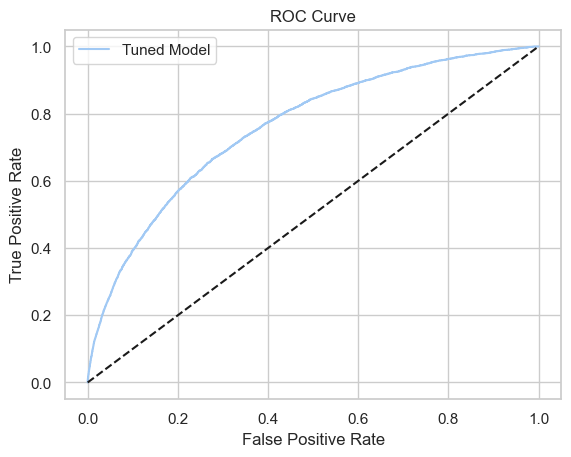

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_val, y_prob)

plt.plot(fpr, tpr, label="Tuned Model")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()